获取数据集：

In [7]:
import zipfile
from random import shuffle

from google.protobuf.duration import from_microseconds
from soupsieve import select_one

with zipfile.ZipFile('mnist.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('./')  # 解压到当前目录


In [1]:
import pandas as pd
mnist = pd.read_csv('./mnist.csv')
mnist.head(5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


处理完成！特征 X 形状: (69999, 784), 标签 y 形状: (69999,)


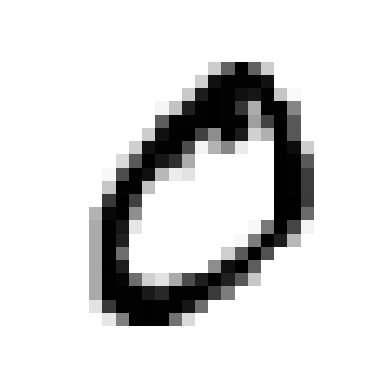

这张图对应的真实数字是: 0


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载本地 CSV
# 看到你截图里文件名叫 mnist.csv
df = pd.read_csv('mnist.csv')

# 2. 分离标签和特征
# 第一列是 label (数字几)，后面 784 列是像素
y = df.iloc[:, 0].values.astype(np.uint8)
X = df.iloc[:, 1:].values

print(f"处理完成！特征 X 形状: {X.shape}, 标签 y 形状: {y.shape}")
# 此时 X 应该是 (样本数, 784)，y 应该是 (样本数,)

# 3. 验证一下：画出第一个数字
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(f"这张图对应的真实数字是: {y[0]}")

In [23]:
# 1. 分离特征和标签
# 在 Kaggle 的 CSV 中，第一列通常是标签(target)，后面 784 列是像素(data)
y = df.iloc[:, 0].values.astype(np.uint8) # 提取第一列作为 y
X = df.iloc[:, 1:].values                # 提取剩余列作为 X

# 2. 现在查看形状就不会报错了
print(f"特征 X 的形状: {X.shape}") # 预期应该是 (样本数, 784)
print(f"标签 y 的形状: {y.shape}")

特征 X 的形状: (69999, 784)
标签 y 的形状: (69999,)


In [24]:
from sklearn.utils import Bunch

# 手动创建一个 Bunch 对象，模仿 fetch_openml 的结构
mnist = Bunch(
    data=X,
    target=y,
    frame=df,  # 原始的 DataFrame
    feature_names=df.columns[1:].tolist(), # 像素列名
    target_names=['label']
)

# 现在验证一下，书上的代码是不是复活了？
print(mnist.data.shape)    # 成功访问 .data
print(mnist['target'].shape) # 成功访问 ['target']

(69999, 784)
(69999,)


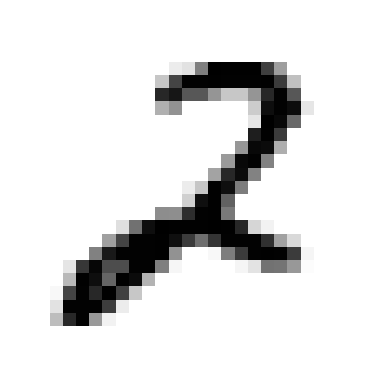

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
some_digit = X[36000]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()

In [26]:
y[36000]

np.uint8(2)

In [27]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

数据洗牌：

In [28]:
import numpy as np

shuffle_index = np.random.permutation(60000)
X_train,y_train = X_train[shuffle_index],y_train[shuffle_index]

训练一个二元分类器：

In [29]:
y_train_5 = (y_train==5)
y_test_5 = (y_test==5)

训练模型:

In [30]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


检测数字5的图像：

In [31]:
sgd_clf.predict([some_digit])

array([False])

# 性能考核

使用交叉验证测量精度：

In [32]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train, cv=3,scoring="accuracy")

array([0.85845, 0.85525, 0.87865])

准确率非常高，令人怀疑，用一个分类器检测一下5与非5：

In [33]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y = None):
        pass
    def predict(self, X):
        return np.zeros((len(X),1),dtype=bool)

测试模型的准确率：

In [34]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3,scoring="accuracy")

array([0.90865, 0.91055, 0.9098 ])

准确率同样很高，说明准确率最好不是首要的分类器性能指标，特别是处理偏斜数据集的时候

## 混淆矩阵

更好的方法是混淆矩阵

要计算混淆矩阵，首先先要有一组预测才能将其与实际目标进行比较，我们可以使用cross_val_predict()

In [37]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

获取混淆矩阵：

In [38]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[52901,  1679],
       [ 1015,  4405]])

混淆矩阵的行表示实际类别，列表示预测类别

一个完美的分类器只有真正类和真负类，，混淆矩阵只在对角线有数值

In [39]:
# 创建完美预测：直接使用真实标签
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54580,     0],
       [    0,  5420]])

## 精度和召回率

在二分类问题中，基于混淆矩阵的四个基本数值（真正例 TP、假正例 FP、真负例 TN、假负例 FN），我们可以定义以下评估指标：

### 精度 (Precision)
精度衡量的是**预测为正例的样本中有多少是真正的正例**，即“查准率”。

$$ \text{Precision} = \frac{TP}{TP + FP} $$

### 召回率 (Recall)
召回率衡量的是**所有真实正例中有多少被正确预测出来**，即“查全率”。

$$ \text{Recall} = \frac{TP}{TP + FN} $$

### F1 分数 (F1-Score)
F1 分数是精度和召回率的**调和平均数**，综合了两者的表现，适用于需要平衡精度和召回率的场景。

$$ F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \times TP}{2 \times TP + FP + FN} $$

> 调和平均数会惩罚那些精度和召回率差异较大的情况，因此只有当两者都高时，F1 分数才会高。

精度：

In [41]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5, y_train_pred)

0.7240302432610125

召回率：

In [42]:
recall_score(y_train_5, y_train_pred)

0.8127306273062731

f1分数：

In [43]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7658205841446454

精度/召回率权衡：

In [44]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([-9914.30710081])

In [46]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

## 决策阈值 (Decision Threshold)

在二分类问题中，许多分类器（如 `SGDClassifier`、`LogisticRegression`、SVM）并不直接输出类别标签，而是输出一个**决策分数**或**概率**。最终的分类结果取决于如何将这个分数与一个**阈值**进行比较。

### 1. 什么是决策阈值？

- 对于输出**概率**的模型（如 `LogisticRegression`），默认阈值通常是 **0.5**：
  如果 $p(y=1) \geq 0.5$，预测为正类 (1)；否则预测为负类 (0)。

- 对于输出**决策函数值**的模型（如 `SGDClassifier` 的 `decision_function` 方法），默认阈值为 **0**：
  如果决策值 $\geq 0$，预测为正类；否则为负类。

这个用来划分正负类的边界值就是**决策阈值**。

### 2. 阈值对精度和召回率的影响

调整阈值会改变**真正例 (TP)**、**假正例 (FP)**、**假负例 (FN)** 的数量，从而影响精度和召回率：

| 阈值调整方向 | 对正类预测的影响 | 精度 (Precision) | 召回率 (Recall) |
|--------------|------------------|-------------------|------------------|
| **提高阈值** | 预测为正类更严格（只选最确信的样本） | 通常升高（假正例减少） | 通常降低（漏掉更多真正例） |
| **降低阈值** | 预测为正类更宽松（更多样本被归为正类） | 通常降低（假正例增加） | 通常升高（捕捉到更多真正例） |

**精度和召回率之间往往存在权衡**，无法同时达到最优，需根据实际业务需求选择。


提升阈值：

In [48]:
threshold = 200000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False, False, False, ..., False, False, False], shape=(60000,))

使用cross_val_predict()函数获得训练集中所有实例的分数，但是需要返回的是决策分数:

In [47]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,method="decision_function")

有了这些分数后就可以计算所有可能的阈值的精度和召回率：

In [49]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds = precision_recall_curve(y_train_5, y_scores)

绘制成图：

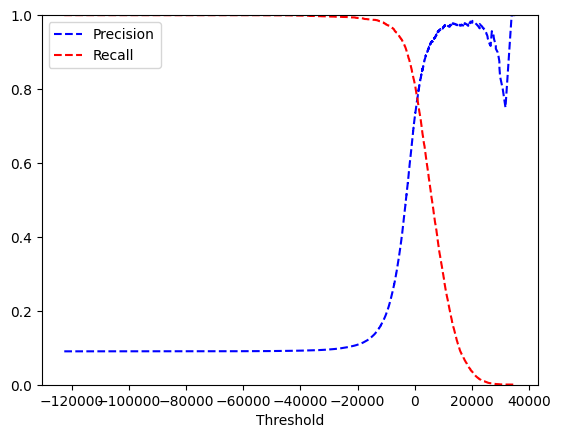

In [51]:
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],'b--',label='Precision')
    plt.plot(thresholds,recalls[:-1],'r--',label='Recall')
    plt.xlabel('Threshold')
    plt.legend(loc = 'upper left')
    plt.ylim([0,1])
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)
plt.show()

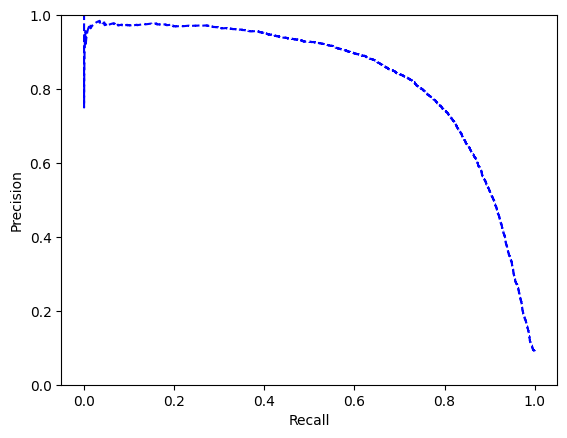

In [52]:
plt.plot(recalls,precisions,'b--',label='Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0,1])
plt.show()

瞄准90%的精度目标：

In [55]:
# 找到精度大于等于 0.90 的第一个索引
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
print(f"能达到 90% 精度的阈值是: {threshold_90_precision}")

能达到 90% 精度的阈值是: 4345.89898372437


In [56]:
y_train_pred_90 = (y_scores >4345)

检查预测结果的精度和召回率：

In [57]:
precision_score(y_train_5, y_train_pred_90)

0.9000561482313307

In [58]:
recall_score(y_train_5, y_train_pred_90)

0.5915129151291513

## ROC曲线：

## ROC 曲线 (Receiver Operating Characteristic Curve)

ROC 曲线是评估二分类器性能的另一个重要工具，尤其适用于**不同类别分布**或**不同误分类成本**的场景。它通过绘制**真正例率 (TPR)** 与**假正例率 (FPR)** 的关系，展示了分类器在所有可能阈值下的表现。

---

### 1. 基本概念

- **真正例率 (True Positive Rate, TPR)**：也称为**召回率**或**灵敏度**，表示真实正例中被正确预测的比例。
  $$ \text{TPR} = \frac{TP}{TP + FN} $$

- **假正例率 (False Positive Rate, FPR)**：表示真实负例中被错误预测为正例的比例。
  $$ \text{FPR} = \frac{FP}{FP + TN} $$

ROC 曲线以 **FPR 为横轴**，**TPR 为纵轴**，描绘了随着分类阈值变化，这两个指标如何变动。

---

### 2. 如何绘制 ROC 曲线

1. **获得每个样本的决策分数**（如 `decision_function` 或 `predict_proba` 的正类概率）。
2. **尝试所有可能的阈值**，从最低分到最高分。
3. **对每个阈值**，计算对应的 TPR 和 FPR。
4. **以 FPR 为 x 轴，TPR 为 y 轴**绘制曲线。

在 scikit-learn 中，可直接使用 `roc_curve` 函数：

---

### 3. ROC 曲线解读

- **对角线**（从 (0,0) 到 (1,1)）代表一个**随机分类器**（TPR = FPR），即完全没有区分能力。
- **左上角** (0,1) 是**理想点**：TPR=1 且 FPR=0，即所有正例都被正确识别，且没有负例被误判。
- **曲线越靠近左上角**，分类器性能越好。
- **曲线下面积 (AUC - Area Under the Curve)** 是衡量分类器整体性能的常用指标：
  - AUC = 1 表示完美分类器。
  - AUC = 0.5 表示与随机猜测无异。
  - 实际中 AUC 通常在 0.5 到 1 之间。

---

### 4. ROC 与 精度-召回率 (PR) 曲线的对比

| 特性 | ROC 曲线 | 精度-召回率曲线 |
|------|----------|------------------|
| **横轴** | 假正例率 (FPR) | 召回率 (Recall) |
| **纵轴** | 真正例率 (TPR) | 精度 (Precision) |
| **适用场景** | 类别相对平衡，或更关注整体排序能力 | 类别高度不平衡，或更关注正类预测的准确性 |
| **对不平衡的敏感性** | 当负例远多于正例时，FPR 会被负例数量拉低，ROC 曲线可能过于乐观 | 直接关注正类的精度和召回率，能更好反映不平衡下的性能 |

**一般建议**：
- 若正负例数量相近，或需要整体评估排序能力，使用 ROC 和 AUC。
- 若正例极少（如欺诈检测、罕见病诊断），应优先使用 PR 曲线。

---


绘制ROC曲线：

In [59]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds = roc_curve(y_train_5, y_scores)

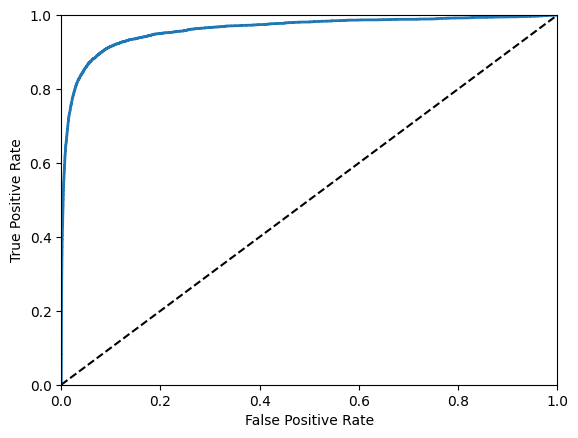

In [61]:
def plot_roc_curve(fpr,tpr,label = None):
    plt.plot(fpr,tpr,linewidth = 2,label=label)
    plt.plot([0,1],[0,1],'k--')
    plt.axis([0,1,0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
plot_roc_curve(fpr,tpr)
plt.show()

计算ROC AUC：

In [62]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9611253395604678

训练随机森林分类器，并计算ROC且与SGD进行对比：

In [63]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,method="predict_proba")

直接使用正类的概率作为分数值：

In [64]:
y_scores_forest = y_probas_forest[:,1]
fpr_forest,tpr_forest,thresholds_forest = roc_curve(y_train_5, y_scores_forest)

绘制曲线：

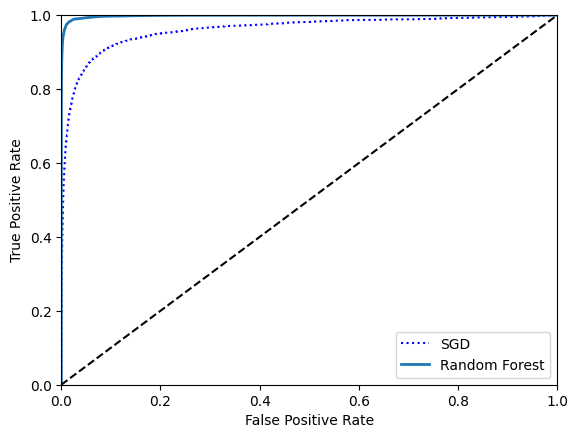

In [66]:
plt.plot(fpr,tpr,'b:',label = 'SGD')
plot_roc_curve(fpr_forest,tpr_forest,'Random Forest')
plt.legend(loc = 'lower right')
plt.show()

曲线分数：

In [67]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983707503390534

# 多类别分类器：

## 多类别分类器 (Multiclass Classification)

在前面我们一直在处理二元分类问题（例如识别数字 5 与非 5）。但在 MNIST 数据集中，原始标签是 0 到 9 共 10 个数字，这就是一个典型的多类别分类问题。本节将系统介绍多类别分类的基本概念、常用策略、实现方法以及评估指标。

---

### 1. 什么是多类别分类？

- **定义**：分类任务中，目标变量 `y` 的可能取值超过两个（例如手写数字识别、图像分类、垃圾邮件过滤中的“正常/垃圾/疑似”等）。
- **与二元分类的关系**：多类别分类可以看作二元分类的自然扩展，但需要处理类别之间的区分。

---

### 2. 多类别分类的常见策略

许多机器学习算法本身只能处理二元分类（如 `SGDClassifier`、`SVM`、`LogisticRegression` 原始形式）。要让它们处理多类别问题，通常有两种策略：

#### 2.1 一对多 / 一对其余 (One-vs-All / One-vs-Rest, OvA / OvR)

- **核心思想**：为每个类别训练一个二元分类器，将该类别作为正类，其余所有类别作为负类。
- **训练**：若有 K 个类别，则训练 K 个二元分类器（例如对于数字 0，分类器 0 负责区分“是 0”与“不是 0”；分类器 1 负责区分“是 1”与“不是 1”……）。
- **预测**：将新样本送入所有 K 个分类器，得到 K 个决策分数（或概率），选择**分数最高**的类别作为最终预测结果。
- **优点**：
  - 分类器数量少（K 个），训练相对高效。
  - 每个分类器可以利用全部训练数据（虽然负类样本远多于正类，但可通过调整类别权重解决）。
- **缺点**：
  - 每个分类器都要面对不平衡数据（正类 vs 所有其他类），可能需要调整阈值或使用类别权重。
- **sklearn 实现**：`OneVsRestClassifier` 是通用的 OvR 包装器；许多分类器（如 `SGDClassifier`、`LogisticRegression`）默认采用 OvR 策略。

#### 2.2 一对一 (One-vs-One, OvO)

- **核心思想**：为每对类别训练一个二元分类器，区分两个特定类别。
- **训练**：若有 K 个类别，则训练 \( K(K-1)/2 \) 个二元分类器（例如区分 0 和 1、0 和 2、1 和 2……）。
- **预测**：将新样本送入所有分类器，每个分类器给出一个预测（属于两个类别之一），最终通过**投票**选出得票最多的类别（若平局，通常选择分数较高的类别）。
- **优点**：
  - 每个分类器只需使用两个类别的数据，训练数据较少，尤其适合训练时间长的算法（如 SVM）。
  - 类别不平衡问题相对较小（两个类别的样本数量可能相近）。
- **缺点**：
  - 分类器数量随类别数平方增长，当 K 很大时训练和预测时间显著增加。
- **sklearn 实现**：`OneVsOneClassifier` 是通用的 OvO 包装器；某些分类器（如 `SVC`）默认采用 OvO 策略。

#### 2.3 原生支持多类别的算法

有些算法直接支持多类别分类，无需策略包装：
- 决策树、随机森林、朴素贝叶斯、神经网络等可以直接输出多类别概率。
- 这些算法内部通过 softmax 回归（多类别逻辑回归）或信息增益等机制处理多类。

---

### 5. 多类别分类的评估指标

- **准确率 (Accuracy)**：最直观，但可能掩盖某些类别的表现。
- **混淆矩阵**：提供全面的错误分析。
- **宏平均 (Macro-average)**：分别计算每个类别的指标（精度、召回率、F1），然后取算术平均，**平等对待每个类别**，不考虑类别样本数。
- **微平均 (Micro-average)**：将所有类别的 TP、FP、FN 汇总后计算总体指标，**受样本数多的类别影响更大**。
- **加权平均 (Weighted-average)**：按每个类别的样本数加权计算指标，是 sklearn 中 `classification_report` 默认提供的。

---

In [68]:
sgd_clf.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [69]:
sgd_clf.predict([some_digit])

array([2], dtype=uint8)

调用decision_function():

In [70]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-35674.29888436, -15359.59866042,   3075.44786808,
         -1854.50370165, -20923.28392625, -14451.44465055,
        -18899.79264342, -45752.95659055,  -2564.5501364 ,
        -11315.76462555]])

In [71]:
np.argmax(some_digit_scores)

np.int64(2)

In [72]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

OvO策略创建一个多类别分类器：

In [74]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array([2], dtype=uint8)

In [75]:
len(ovo_clf.estimators_)

45

In [76]:
forest_clf.fit(X_train, y_train)
forest_clf.predict([some_digit])

array([2], dtype=uint8)

In [77]:
forest_clf.predict_proba([some_digit])

array([[0.  , 0.  , 0.98, 0.01, 0.  , 0.  , 0.01, 0.  , 0.  , 0.  ]])

In [78]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3,scoring="accuracy")

array([0.95695, 0.96455, 0.9438 ])

特征缩放标准化：

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf,X_train_scaled,y_train_5,cv=3,scoring="accuracy")

array([0.9686 , 0.9697 , 0.97085])

# 误差分析

查看混淆矩阵：

In [82]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3,n_jobs = -1)
conf_mx = confusion_matrix(y_train,y_train_pred)
conf_mx

array([[5588,    0,   15,    7,    8,   36,   32,    5,  231,    1],
       [   1, 6418,   41,   19,    3,   39,    6,    8,  198,    9],
       [  26,   29, 5241,   84,   74,   21,   63,   37,  376,    7],
       [  24,   18,  112, 5235,    0,  192,   25,   44,  421,   60],
       [  11,   14,   38,    9, 5203,   10,   35,   18,  350,  154],
       [  28,   18,   24,  157,   51, 4419,   82,   19,  558,   64],
       [  26,   17,   49,    2,   39,   83, 5548,    5,  149,    0],
       [  23,   13,   49,   25,   46,   11,    5, 5682,  209,  203],
       [  13,   55,   47,   99,    3,  121,   31,    6, 5436,   40],
       [  24,   20,   29,   63,  120,   30,    1,  168,  396, 5098]])

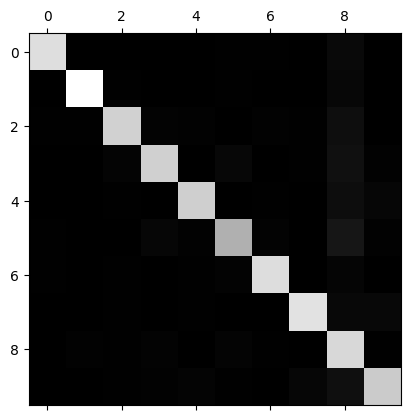

In [83]:
plt.matshow(conf_mx,cmap = plt.cm.gray)
plt.show()

计算错误率：

In [84]:
row_sums = conf_mx.sum(axis=1,keepdims=True)
norm_conf_mx = conf_mx / row_sums

用0填充对角线，只保留错误

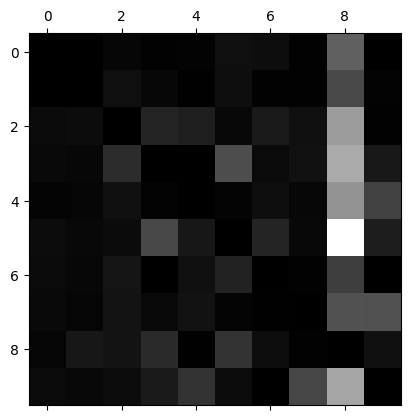

In [86]:
np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx,cmap = plt.cm.gray)
plt.show()

分析单个的错误（以3和5为例）：

In [87]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # 这行代码负责将展平的 784 维向量还原为 28x28 的图像
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = plt.cm.binary, **options)
    plt.axis("off")

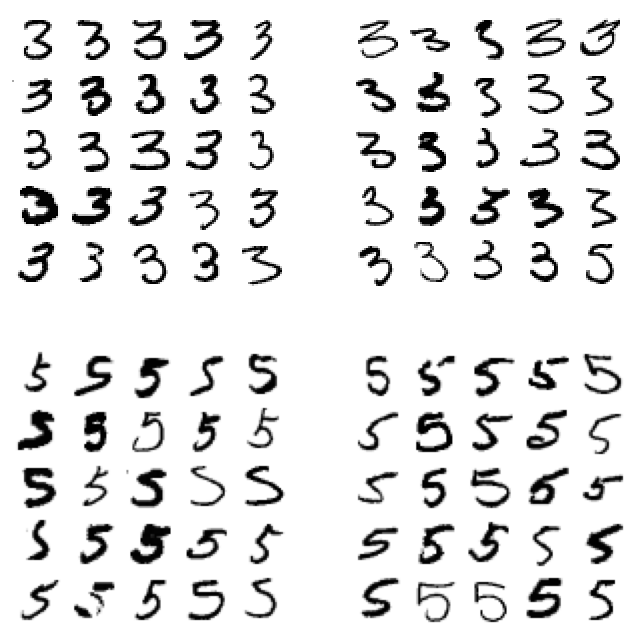

In [89]:
cl_a,cl_b = 3,5
X_aa = X_train[(y_train==cl_a) & (y_train_pred==cl_a)]
X_ab = X_train[(y_train==cl_a) & (y_train_pred==cl_b)]
X_ba = X_train[(y_train==cl_b) & (y_train_pred==cl_a)]
X_bb = X_train[(y_train==cl_b) & (y_train_pred==cl_b)]

plt.figure(figsize = (8,8))
plt.subplot(221);plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222);plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223);plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224);plot_digits(X_bb[:25], images_per_row=5)
plt.show()


## 多标签分类

一个实例，多个类别：

In [90]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train>=7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [91]:
knn_clf.predict([some_digit])

array([[False, False]])

用f1分数评估标签分类器：

In [92]:
y_train_knn_pred = cross_val_predict(knn_clf,X_train,y_train,cv=3,n_jobs = -1)
f1_score(y_train,y_train_knn_pred,average='macro')

0.9685820471602484

## 多输出分类

In [94]:
import numpy as np
import numpy.random as rnd
noise = rnd.randint(0,100,(len(X_train),784))
X_train_mod = X_train+noise
noise = rnd.randint(0,100,(len(X_test),784))
X_test_mod = X_test+noise

y_train_mod = X_train
y_test_mod = X_test

In [95]:
some_index = 0
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict(X_test_mod[some_index])
plot_digits(clean_digit)

ValueError: Expected 2D array, got 1D array instead:
array=[ 61  82  31   3  18  73  69  99  97  53   0  73  22  84  45  46  85   9
   4  86  14  16  57  99  88  93   0  29  85  83  19  55  19  87  85  74
  24  53  10  80  32  99  57  84  61  78  49  67  89  16  63  26  42  80
  85  96   9  62  91  37  10  92  94  80  30  87  56  65  82  48  13  91
  10  69  31   4  35   0  97   7  41  47  80  51  91  96  78   6  77  19
  27  45  77  17 130 127 213 269 259 167 151  87   8  82  58  44  88  66
  97  34  29  27  62  75  98  88  50  37  93  61  96 199 310 300 273 339
 277 268 289  46  48  94  80  29  55  59  25  16  80   6  82  37  25  51
  95  47  56  82 228 255 299 327 280 148 256 256 306 182  27  39  11  90
  10   3  14  71  67  29  78  94  41  51  14  10  97  91 329 270 302 127
 111  26  77 214 282 165  97  26  72  21   0  25  10  93  93  60  85  56
  34  39  55  88  41 167 337 293  98  35  37  63 208 270 253  99  71  34
  78  13  11  37  28  89  33  29  38  33  26  19  62  54  61  79  96  79
  59  93  23   1 231 264 276 137  81  75  29  52  83  24  77  27  72  82
  92  76  92  87  60  38  36  82   2  98  34  80  67 163 256 293 232  10
  32  56  75  94  92  17  61   9  66  18  80  13  26  24  22  35  32   7
  15  63  93  32  94 326 334 316 150  70  15  50  24  30  76  55  88  89
  29  40  88  97  87  55  63  66  38  61  23  21  25  54 142 333 306 227
  60  57  48  14  81  46  43  87  47  18  16  55   0  54  80  61  52  85
  35  49  47  22  60 191 333 323 183  70  95  91   1  35  23  66  58  20
  66  61  72  91  99  61  55  41  77   2  61   7  67  81 123 318 315 244
 106  74  76   9  36  25  42  11  23  69  73  52  23  61  52  51  25  25
  57  77  72  29  34  36 215 281 276 178   6  94  79  52  82   6  56  90
  44  87  57  89  40  86   1  22  89  14  73  40  48  86  35 137 271 314
 209  59  43  20  35  31  51   2  28   4  84  67  61  64  51  92  13  21
  95  71  10  44  30  89  42 206 304 276 186  80  18  50  57  16  31  32
  70  25  59  66  81  91   4  23  24  72   5  51  31  59  71   5 169 328
 319 243 110  66  69  47  60  92  29   4  46  65  56  34  35  86  13  81
  87  18  18   5  79  16  96  76 331 277 310  51  68  51  32  93  24  11
  96   0  72  93  10  11  11  32  69  23  64  18  24  53   6  79  57  70
 283 291 260  91  85 101  64  54  44  51  77  77  81  88 236 156 160 192
  19   8   4  31  27  97   3  11   7  72 322 329 277 320 330 291 347 312
 227 148 207 337 297 335 269 253 334 331 131  74  20  66   4   5  46  38
  84  34 239 333 300 286 289 327 277 254 310 265 330 291 342 330 260 268
 171 117  95  72  66  60  13  79  88  18  68   4   0 146 132 194 220 247
 255 279 336 164 185 160  72  13   7  63  43   2  33  39  55  44  33  33
  34  64   4  83  80  32  74  13  64  73  68  54  14  56   7  31  63   0
  52  80  34  17   5  10  76  28  32  83  92  30  93  93  35  72  42  11
  85   3  75   5   3  50  87  76  86  69  80  56  54  18  52  13  60  31
  64   5  21  86  46  77  65  88  18  54   2  80  39  19  28  93  13  94
  96  37  71  89  17  89  54  65  47  93  75  67  23  55  95  73  58  80
  73   3  98  32  27  51  14  79  99  97  40  41  18  78  67  21  89   5
  33  40  63  38  81   2  23  63  71  95  30  13  10  77  33  10  97  26
  81  60   1  50  18  43  68  72  49   8].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

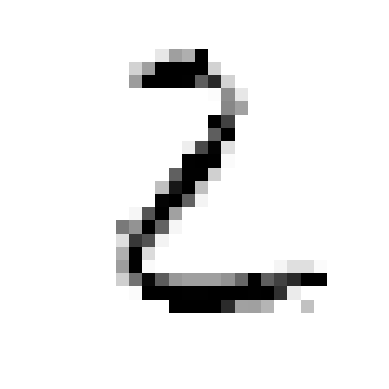

In [96]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# 2. 初始化并训练模型
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

# 3. 定义索引并预测
some_index = 0  # 选一张图片，比如第 0 张
clean_digit = knn_clf.predict([X_test_mod[some_index]])

# 4. 展示结果
plot_digits(clean_digit)
plt.show()